### **Importing Libraries**

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mne
from mne.time_frequency import psd_array_welch
from mne_connectivity import spectral_connectivity_epochs
from tensorpac import Pac

# Set log-level to reduce verbosity
mne.set_log_level("WARNING")

### **Loading Sample Data**

In [2]:
# Load sample dataset
data_path = mne.datasets.sample.data_path()
raw_fname = os.path.join(data_path, 'MEG/sample/sample_audvis_filt-0-40_raw.fif')
raw = mne.io.read_raw_fif(raw_fname, preload=True)

# High-pass filter the data
raw.filter(l_freq=0.5, h_freq=40, verbose=False)

c:\Users\lacom\.conda\envs\xtra\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


<Raw | sample_audvis_filt-0-40_raw.fif, 376 x 41700 (277.7 s), ~122.8 MiB, data loaded>

### **Extracting Events and Creating Epochs**

C:\Users\lacom\AppData\Local\Temp\ipykernel_14224\298206401.py:7: RuntimeWarning: event 5 missing from event_id will be ignored
  fig = mne.viz.plot_events(events, sfreq=raw.info['sfreq'], event_id=event_id);
C:\Users\lacom\AppData\Local\Temp\ipykernel_14224\298206401.py:7: RuntimeWarning: event 32 missing from event_id will be ignored
  fig = mne.viz.plot_events(events, sfreq=raw.info['sfreq'], event_id=event_id);


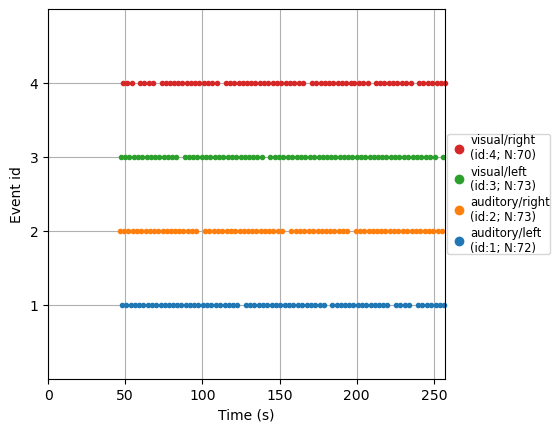

In [74]:
# Extract events 
events = mne.find_events(raw, stim_channel='STI 014', verbose=False)


event_id = {"visual/left": 3, "visual/right": 4,
            "auditory/left": 1, "auditory/right": 2}
fig = mne.viz.plot_events(events, sfreq=raw.info['sfreq'], event_id=event_id);

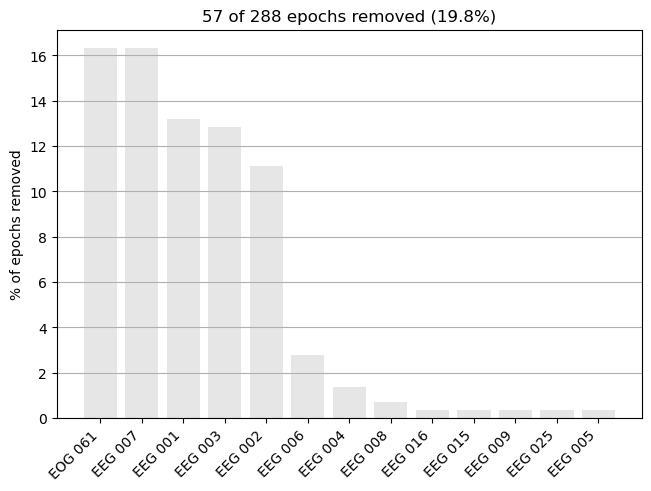

In [4]:

# Epochs parameters
tmin = -0.2  # Start of epoch in seconds
tmax = 0.5   # End of epoch in seconds
baseline = (None, 0)  # No baseline correction
reject = dict(eeg=80e-6, eog=150e-6)
picks = mne.pick_types(raw.info, eeg=True, meg=False, eog=True, stim=False, exclude='bads')

epochs = mne.Epochs(raw, events, event_id, tmin, tmax, proj=True, picks=picks, 
                    baseline=baseline, reject=reject, preload=True)


# Separate epochs for each event type
epochs_event1 = epochs['auditory/left']
epochs_event2 = epochs['auditory/right']
epochs_event3 = epochs['visual/left']
epochs_event4 = epochs['visual/right']


epochs.drop_bad()

fig = epochs.plot_drop_log()

c:\Users\lacom\.conda\envs\xtra\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


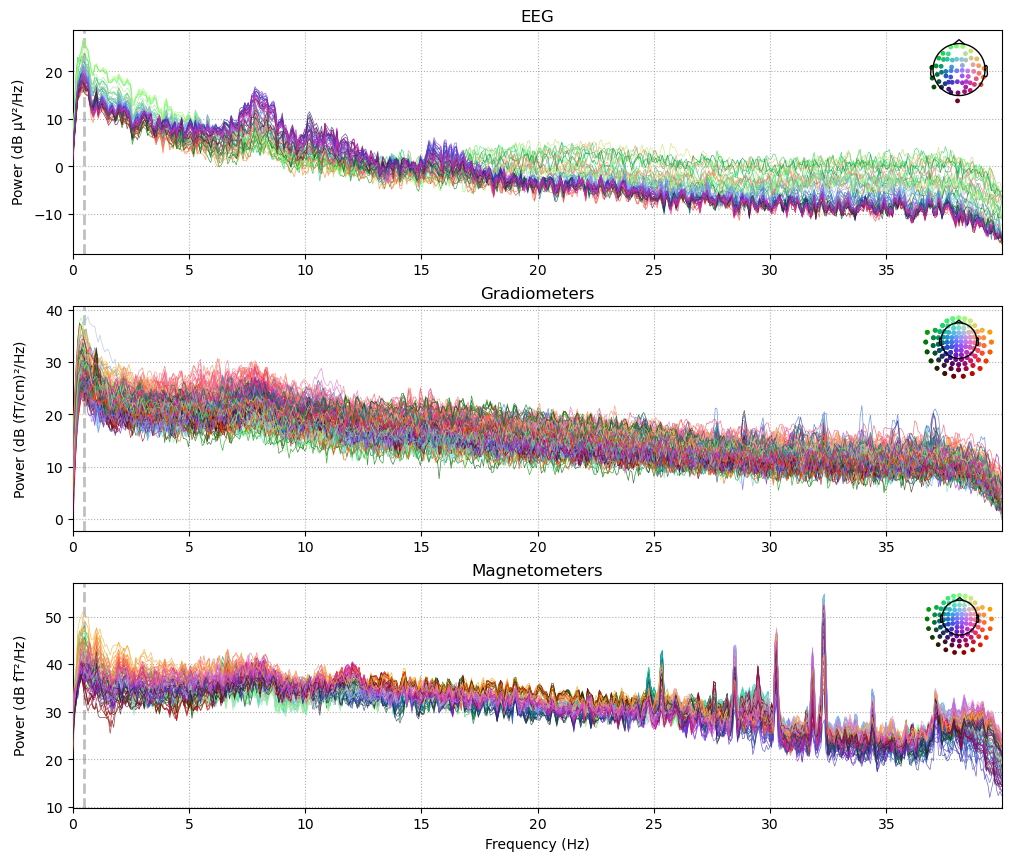

In [13]:
# Visualization Epochs
fig = raw.plot_psd(fmax=40)

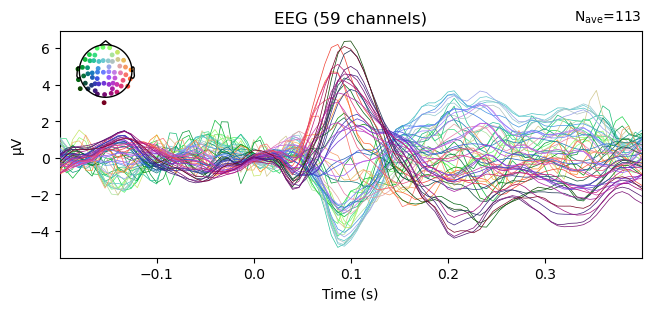

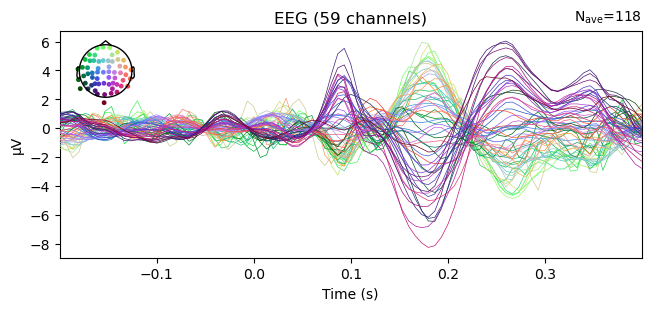

In [36]:
# Accessing and indexing epochs by condition
evoked_auditory = epochs['auditory'].average().pick_types(eeg=True)
evoked_auditory.crop(None, 0.4) # Beginning of evoked until 0.4s after stimulus onset.
fig = evoked_auditory.plot(spatial_colors=True)

evoked_visual = epochs['visual'].average().pick_types(eeg=True)
evoked_visual.crop(None, 0.4) # Beginning of evoked until 0.4s after stimulus onset.
fig = evoked_visual.plot(spatial_colors=True)

In [ ]:
fig =evoked.plot_topomap(ch_type='eeg', times=[0.05, 0.1, 0.15])

In [7]:
# Epochs_data is a 3D array of dimension (239 epochs, 306 channels, 106 time instants).
epochs_data = epochs.get_data()
type(epochs_data), epochs_data.shape

(numpy.ndarray, (231, 60, 106))

In [ ]:
# evoked = epochs.average() # Average the epochs to get the evoked response (ERF/ERP)
# fig =evoked.plot_topomap(ch_type='eeg', times=[0.05, 0.1, 0.15])

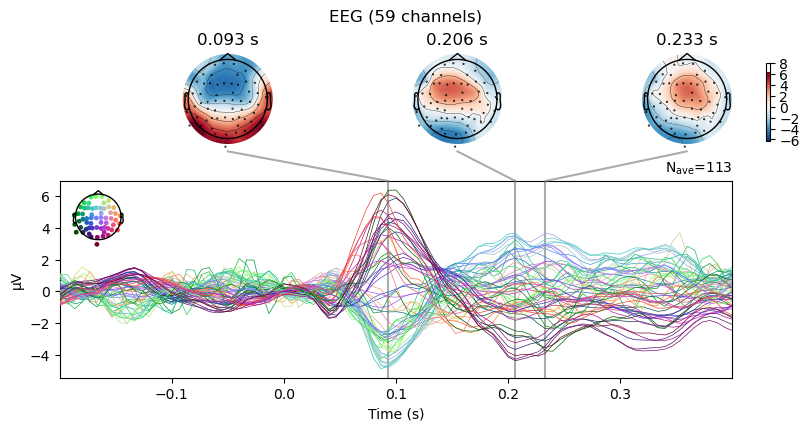

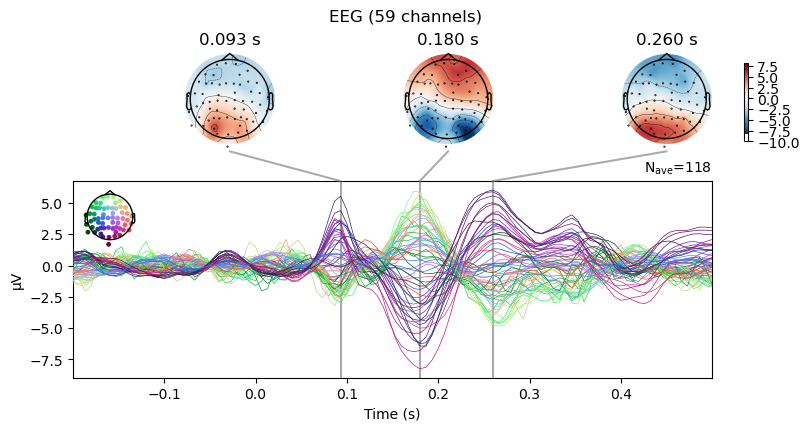

In [31]:
# Visualize Topographies
figs = evoked_auditory.plot_joint()
figs = evoked_visual.plot_joint()

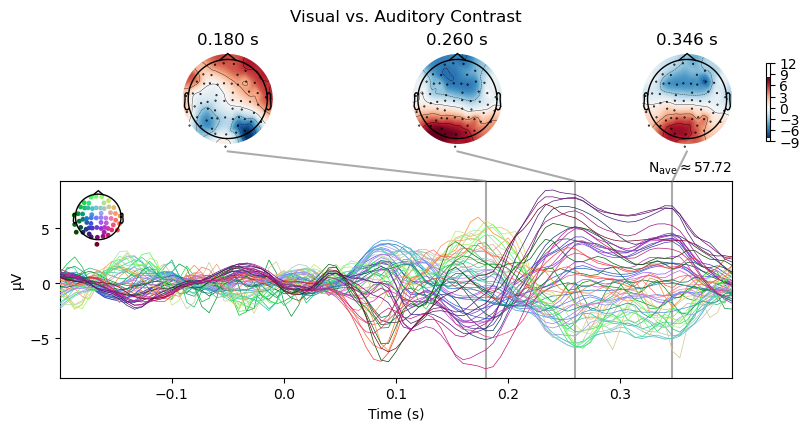

Number of Epochs per Evoked Response: 57.72294372294373


In [58]:
# Compute the contrast (difference) between visual and auditory stimuli
contrast = mne.combine_evoked([evoked_visual, evoked_auditory], weights=[1, -1])

# Visualize the contrast as a joint plot
fig_difference = contrast.plot_joint(title="Visual vs. Auditory Contrast")
print('Number of Epochs per Evoked Response:' ,contrast.nave)

### **Power Spectral Density (PSD)**

In [ ]:
# Separate epochs for each event type
epochs_event1 = epochs['auditory/left']
epochs_event2 = epochs['auditory/right']
epochs_event3 = epochs['visual/left']
epochs_event4 = epochs['visual/right']



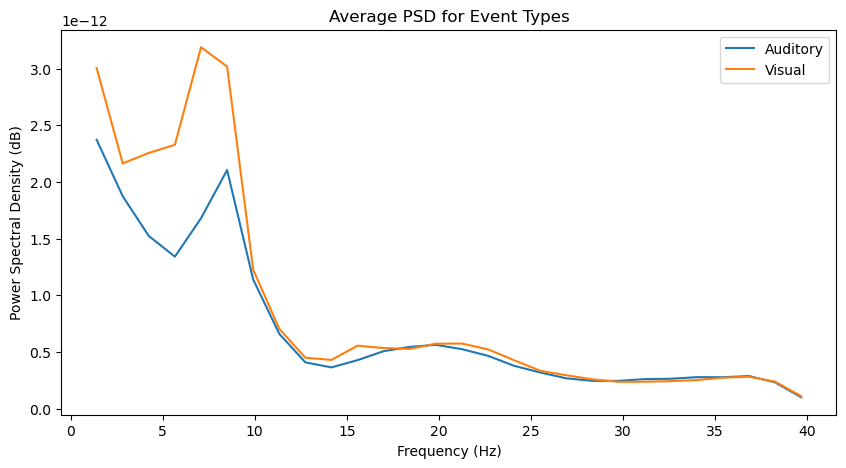

In [62]:

# Compute PSD for each event type
def compute_psd(epochs, sfreq):
    data = epochs.get_data()
    psd, freqs = [], None
    for ep in data:
        n_times = ep.shape[-1]
        n_fft = min(2048, n_times)
        psd_epoch, freqs = psd_array_welch(ep, sfreq=sfreq, fmin=1, fmax=40, n_fft=n_fft, n_overlap=n_fft // 2)
        psd.append(psd_epoch)
    return np.array(psd), freqs

sfreq = epochs.info['sfreq']
psd_event1, freqs = compute_psd(epochs['auditory'], sfreq)
psd_event2, freqs = compute_psd(epochs['visual'], sfreq)

event1 = 'Auditory'
event2 = 'Visual'

# Plot PSD comparison
plt.figure(figsize=(10, 5))
plt.plot(freqs, psd_event1.mean(axis=(0, 1)), label=event1)
plt.plot(freqs, psd_event2.mean(axis=(0, 1)), label=event2)
plt.title("Average PSD for Event Types")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (dB)")
plt.legend()
plt.show()

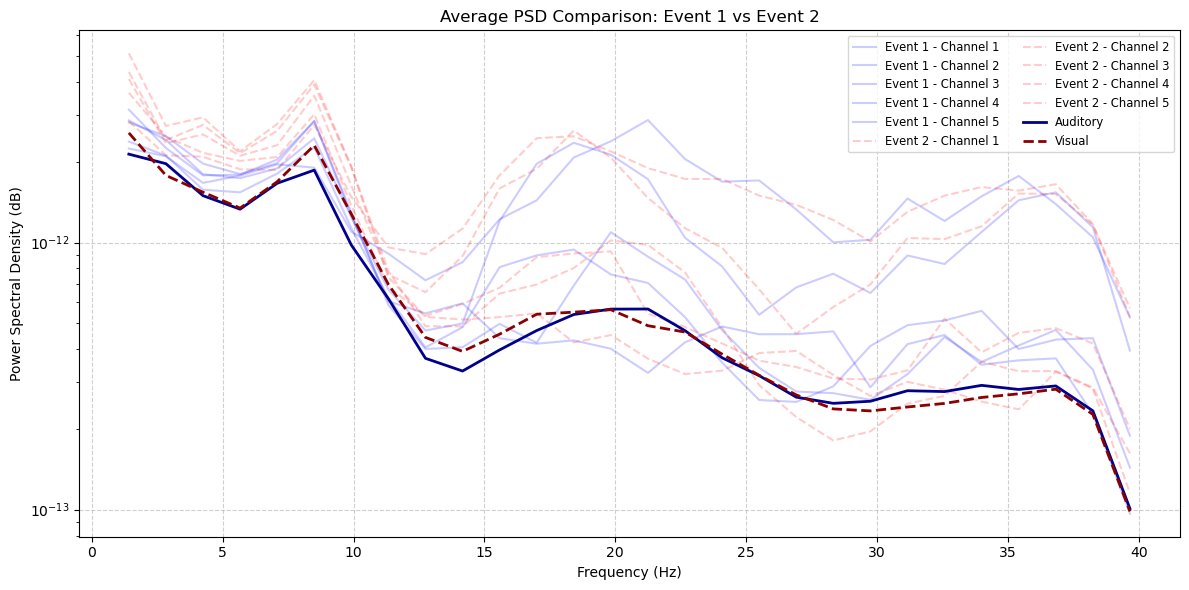

In [66]:


def compute_psd_for_epochs(epochs, fmin=1, fmax=40):
    """Compute Power Spectral Density (PSD) for given epochs."""
    data = epochs.get_data()  # Shape: (n_epochs, n_channels, n_times)
    sfreq = epochs.info['sfreq']

    psd = []
    freqs = None

    # Loop through epochs to calculate PSD
    for ep in data:
        n_times = ep.shape[-1]  # Length of the time series
        n_fft = min(2048, n_times)  # Ensure n_fft does not exceed n_times
        psd_epoch, freqs = psd_array_welch(ep, sfreq=sfreq, fmin=fmin, fmax=fmax, n_fft=n_fft, n_overlap=n_fft // 2)
        psd.append(psd_epoch)

    psd = np.array(psd)  # Shape: (n_epochs, n_channels, n_freqs)
    return psd, freqs

# Compute PSD for both events
psd_event1, freqs_event1 = compute_psd_for_epochs(epochs_event1)
psd_event2, freqs_event2 = compute_psd_for_epochs(epochs_event2)

# Average PSD across epochs for both events
avg_psd_event1 = psd_event1.mean(axis=0)  # Shape: (n_channels, n_freqs)
avg_psd_event2 = psd_event2.mean(axis=0)  # Shape: (n_channels, n_freqs)

# Visualization of Average PSD for Event 1 and Event 2
plt.figure(figsize=(12, 6))

# Plot Event 1
for ch_idx, ch_psd in enumerate(avg_psd_event1):
    if ch_idx < 5:  # Plot only the first 5 channels to avoid clutter
        plt.plot(freqs_event1, ch_psd, label=f"Event 1 - Channel {ch_idx+1}", color='blue', alpha=0.2)

# Plot Event 2
for ch_idx, ch_psd in enumerate(avg_psd_event2):
    if ch_idx < 5:  # Plot only the first 5 channels
        plt.plot(freqs_event2, ch_psd, label=f"Event 2 - Channel {ch_idx+1}", color='red', linestyle="--", alpha=0.2)

# Overlay the average across all channels
avg_psd_event1_mean = avg_psd_event1.mean(axis=0)
avg_psd_event2_mean = avg_psd_event2.mean(axis=0)
plt.plot(freqs_event1, avg_psd_event1_mean, label=event1, color='darkblue', linewidth=2)
plt.plot(freqs_event2, avg_psd_event2_mean, label=event2, color='darkred', linewidth=2, linestyle="--")

# Optional: Add a log scale for the y-axis
plt.yscale("log")

# Plot labels and legend
plt.title("Average PSD Comparison: Event 1 vs Event 2")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (dB)")
plt.legend(loc="upper right", ncol=2, fontsize="small")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.show()


In [67]:

# --- Frequency Band Analysis ---
# Define frequency bands
bands = {
    "Delta": (1, 4),
    "Theta": (4, 8),
    "Alpha": (8, 13),
    "Beta": (13, 30),
    "Gamma": (30, 40),
}

# Helper function to compute average PSD for frequency bands
def compute_band_psd(avg_psd, freqs, bands, ch_names):
    """Calculate mean PSD for defined frequency bands."""
    band_psd_df = pd.DataFrame(index=ch_names)
    for band, (fmin, fmax) in bands.items():
        band_indices = np.where((freqs >= fmin) & (freqs < fmax))[0]  # Indices of frequencies in this band
        band_psd_df[band] = avg_psd[:, band_indices].mean(axis=1)  # Average PSD across band frequencies
    band_psd_df.index.name = "Electrode"
    return band_psd_df

# Compute Band PSD for Event 1 and Event 2
band_psd_event1 = compute_band_psd(avg_psd_event1, freqs_event1, bands, epochs_event1.ch_names)
band_psd_event2 = compute_band_psd(avg_psd_event2, freqs_event2, bands, epochs_event2.ch_names)

# Print Frequency Band PSD DataFrames for both events

band_psd_event1.head()
band_psd_event2.head()


,Delta,Theta,Alpha,Beta,Gamma
Electrode,,,,,
EEG 001,3.227499e-12,2.324128e-12,1.649210e-12,1.253148e-12,1.143399e-12
EEG 002,3.386556e-12,2.514072e-12,1.771988e-12,4.037010e-13,2.574219e-13
EEG 003,3.923476e-12,2.640944e-12,1.814490e-12,5.648420e-13,2.834103e-13
EEG 004,2.485077e-12,1.949349e-12,1.527276e-12,1.712112e-12,1.333971e-12
EEG 005,3.064732e-12,2.094420e-12,1.403539e-12,5.626680e-13,3.996248e-13


In [68]:
# Initialize an empty list to collect reshaped data
reshaped_data = []

# Loop through events (Event 1 and Event 2)
for event_id, band_psd_df in enumerate([band_psd_event1, band_psd_event2], start=1):
    # Add a column for the event type (Event 1 or Event 2)
    band_psd_df["Event"] = event_id

    # Convert the DataFrame into a long format (one row per electrode and frequency band)
    long_format = band_psd_df.reset_index().melt(
        id_vars=["Electrode", "Event"],
        var_name="Frequency Band",
        value_name="Power"
    )

    # Create a column combining "Electrode" and "Frequency Band" as the feature
    long_format["Feature"] = long_format["Electrode"] + " x " + long_format["Frequency Band"]

    # Pivot to a wide format where each feature (electrode x frequency band) becomes a column
    wide_format = long_format.pivot_table(
        index="Event",  # Use Event as the index
        columns="Feature",  # Columns for each electrode x frequency band feature
        values="Power"  # Values for the features
    )

    # Since you only have one subject, manually add the Subject ID
    wide_format["Subject"] = 1  # Single subject, so subject ID is 1

    # Reset index to make the DataFrame flat
    reshaped_data.append(wide_format.reset_index(drop=True))

# Concatenate data for both events
final_reshaped_df = pd.concat(reshaped_data, ignore_index=True)

# Add the Event column manually after concatenation
final_reshaped_df["Event"] = np.repeat([1, 2], [1, 1])  # Event 1 and Event 2 (both with one subject)

# Reorder columns: Subject, all features, Event
columns = ["Subject"] + [col for col in final_reshaped_df.columns if col not in ["Subject", "Event"]] + ["Event"]
final_reshaped_df = final_reshaped_df[columns]

# Display the final DataFrame
final_reshaped_df.head()


Feature,Subject,EEG 001 x Alpha,EEG 001 x Beta,EEG 001 x Delta,EEG 001 x Gamma,EEG 001 x Theta,EEG 002 x Alpha,EEG 002 x Beta,EEG 002 x Delta,EEG 002 x Gamma,...,EEG 060 x Beta,EEG 060 x Delta,EEG 060 x Gamma,EEG 060 x Theta,EOG 061 x Alpha,EOG 061 x Beta,EOG 061 x Delta,EOG 061 x Gamma,EOG 061 x Theta,Event
0,1,1.210005e-12,1.199090e-12,2.644707e-12,1.048813e-12,1.814234e-12,1.314476e-12,4.312250e-13,2.660961e-12,3.246385e-13,...,1.693922e-13,4.280923e-12,4.942460e-14,2.590509e-12,5.981251e-13,4.188911e-13,4.370877e-12,3.638502e-13,1.681163e-12,1
1,1,1.649210e-12,1.253148e-12,3.227499e-12,1.143399e-12,2.324128e-12,1.771988e-12,4.037010e-13,3.386556e-12,2.574219e-13,...,1.368755e-13,3.214448e-12,4.020061e-14,2.000878e-12,7.392801e-13,4.510797e-13,1.453115e-11,3.488521e-13,2.925908e-12,2


### **Phase Amplitude Coupling (PAC)**

In [77]:
# Compute PAC for each event type
def compute_pac(epochs, sfreq):
    data_mean = epochs.get_data().mean(axis=0)  # Average across epochs
    pac = Pac(idpac=(1, 2, 4), f_pha=(4, 8), f_amp=(30, 90))
    pac_values = pac.filterfit(sfreq, data_mean)
    return pac_values

pac_event1 = compute_pac(epochs_event1, sfreq)
pac_event2 = compute_pac(epochs_event2, sfreq)
pac_event3 = compute_pac(epochs_event3, sfreq)
pac_event4 = compute_pac(epochs_event4, sfreq)

# Display PAC results
pac_avg_event1 = pac_event1.mean(axis=(0, 1))
pac_avg_event2 = pac_event2.mean(axis=(0, 1))
pac_avg_event3 = pac_event3.mean(axis=(0, 1))
pac_avg_event4 = pac_event4.mean(axis=(0, 1))
pac_df = pd.DataFrame({
    "Electrode": epochs.ch_names,
    "Auditory/left": pac_avg_event1,
    "Auditory/right": pac_avg_event2,
    "Visual/left": pac_avg_event3,
    "Visual/right": pac_avg_event4
})

print("PAC DataFrame:")
pac_df.head()




Phase Amplitude Coupling object defined
    extract phases (n_pha=1) and amplitudes (n_amps=1)
    true PAC estimation using Mean Vector Length (MVL, Canolty et al. 2006)
    compute surrogates (Swap amplitude time blocks (Bahramisharif et al. 2013), 200 permutations, random_state=4687)
    infer p-values at (p=0.05, mcp=maxstat)
    normalize true PAC estimation by surrogates (Substract the mean and divide by the deviation of the surrogates)
Phase Amplitude Coupling object defined
    extract phases (n_pha=1) and amplitudes (n_amps=1)
    true PAC estimation using Mean Vector Length (MVL, Canolty et al. 2006)
    compute surrogates (Swap amplitude time blocks (Bahramisharif et al. 2013), 200 permutations, random_state=512)
    infer p-values at (p=0.05, mcp=maxstat)
    normalize true PAC estimation by surrogates (Substract the mean and divide by the deviation of the surrogates)
Phase Amplitude Coupling object defined
    extract phases (n_pha=1) and amplitudes (n_amps=1)
    true PAC

PAC DataFrame:


,Electrode,Auditory/left,Auditory/right,Visual/left,Visual/right
0,EEG 001,1.112495,-0.109755,1.395450,1.822628
1,EEG 002,1.492146,1.379717,-0.166072,1.332836
2,EEG 003,0.971075,0.907729,0.305268,1.723555
3,EEG 004,0.226008,-0.182576,2.023433,-0.061374
4,EEG 005,-1.503694,0.086117,1.280716,-1.427039


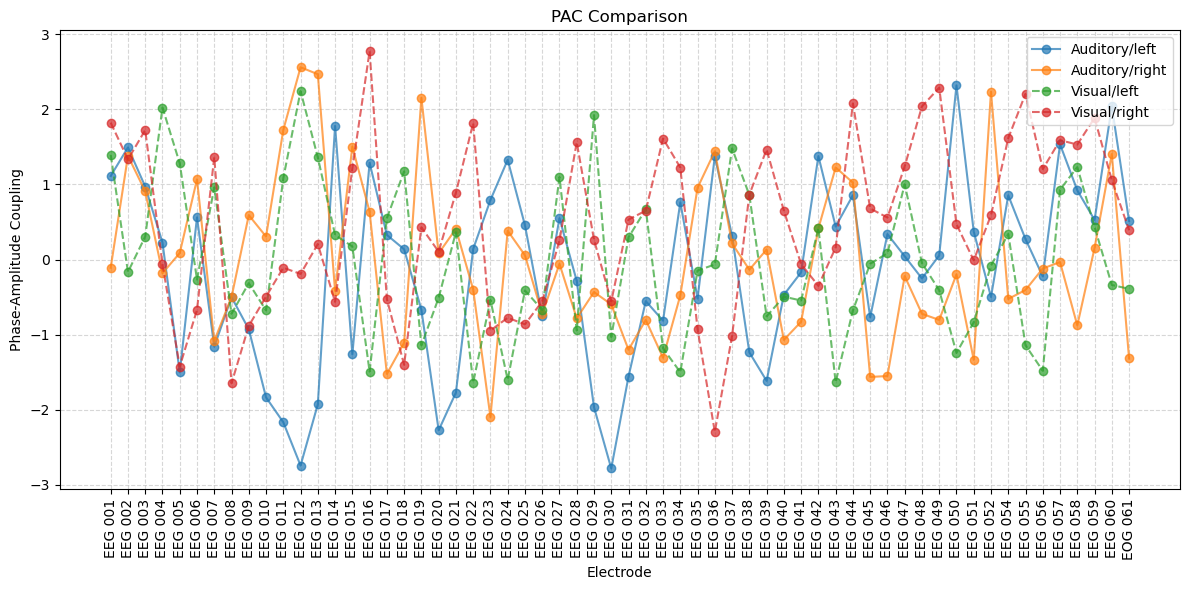

In [90]:
plt.figure(figsize=(12, 6))

# Plot PAC for Event 1
plt.plot(pac_df['Electrode'], pac_df['Auditory/left'], label="Auditory/left",  marker='o', linestyle='-', alpha=0.7)

# Plot PAC for Event 2
plt.plot(pac_df['Electrode'], pac_df['Auditory/right'], label="Auditory/right", marker='o', linestyle='-', alpha=0.7)

# Plot PAC for Event 3
plt.plot(pac_df['Electrode'], pac_df['Visual/left'], label="Visual/left", marker='o', linestyle='--', alpha=0.7)

# Plot PAC for Event 4
plt.plot(pac_df['Electrode'], pac_df['Visual/right'], label="Visual/right", marker='o', linestyle='--', alpha=0.7)

# Customize plot
plt.title("PAC Comparison")
plt.xlabel("Electrode")
plt.ylabel("Phase-Amplitude Coupling")
plt.legend(loc="upper right")
plt.xticks(rotation=90)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

plt.show()


### **Morlet wavelets**

<Figure size 800x600 with 0 Axes>

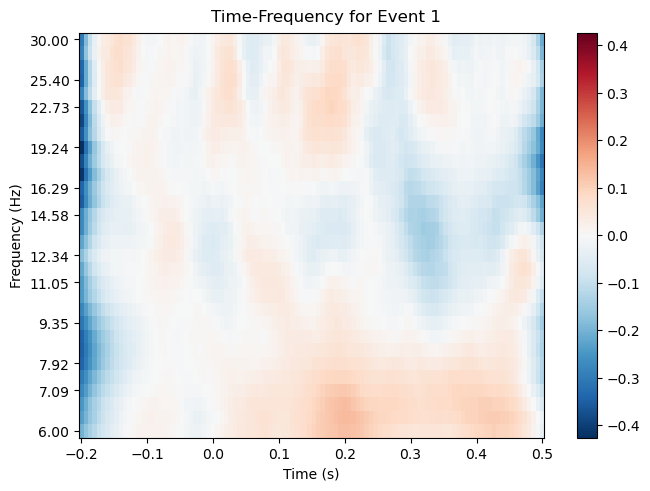

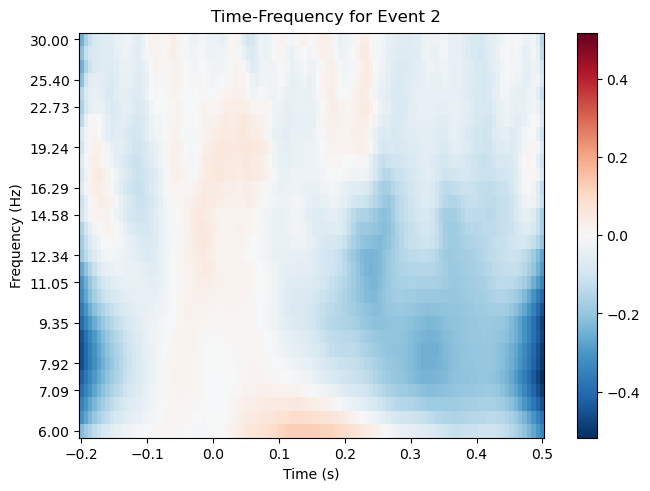

In [86]:
from mne.time_frequency import tfr_multitaper

# Perform Time-Frequency analysis using Morlet wavelets
freqs = np.logspace(np.log10(6), np.log10(30), 30)  # Frequency range (e.g., 6-30 Hz)
tfr_event1 = tfr_multitaper(epochs['auditory'], freqs=freqs, time_bandwidth=2, n_cycles=2, return_itc=False)
tfr_event2 = tfr_multitaper(epochs['visual'], freqs=freqs, time_bandwidth=2, n_cycles=2, return_itc=False)

# Plot the time-frequency representation for the first epoch
plt.figure(figsize=(8, 6))
tfr_event1.plot([0], baseline=(-0.1, 0), mode='logratio', title="Time-Frequency for Event 1")
tfr_event2.plot([1], baseline=(-0.1, 0), mode='logratio', title="Time-Frequency for Event 2")
plt.show()


### **Compute Coherence**

In [83]:
# Compute Coherence for each event type
def compute_coherence(epochs, sfreq):
    coh = spectral_connectivity_epochs(epochs, method='coh', sfreq=sfreq, fmin=8, fmax=40, faverage=True, verbose=False)
    return coh.get_data()

coh_event1 = compute_coherence(epochs['auditory'], sfreq)
coh_event2 = compute_coherence(epochs['visual'], sfreq)

print(f"Coherence Event 1 Shape: {coh_event1.shape}")
print(f"Coherence Event 2 Shape: {coh_event2.shape}")

Coherence Event 1 Shape: (3600, 1)
Coherence Event 2 Shape: (3600, 1)


### **Phase Locking Value (PLV)**

In [84]:

# Compute PLV for each event type
def compute_plv(epochs, sfreq):
    plv = spectral_connectivity_epochs(epochs, method='plv', sfreq=sfreq, fmin=8, fmax=13, faverage=True, verbose=False)
    return plv.get_data()

plv_event1 = compute_plv(epochs['auditory'], sfreq)
plv_event2 = compute_plv(epochs['visual'], sfreq)

print(f"PLV Event 1 Shape: {plv_event1.shape}")
print(f"PLV Event 2 Shape: {plv_event2.shape}")

PLV Event 1 Shape: (3600, 1)
PLV Event 2 Shape: (3600, 1)
